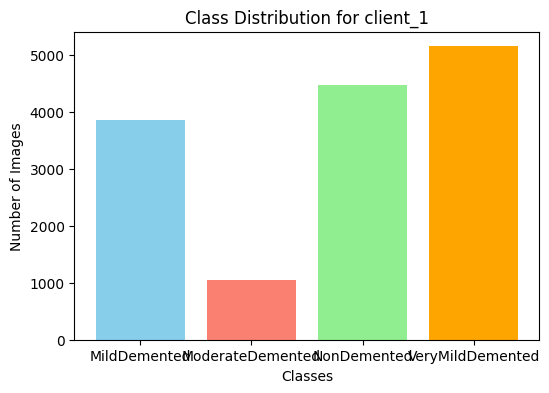

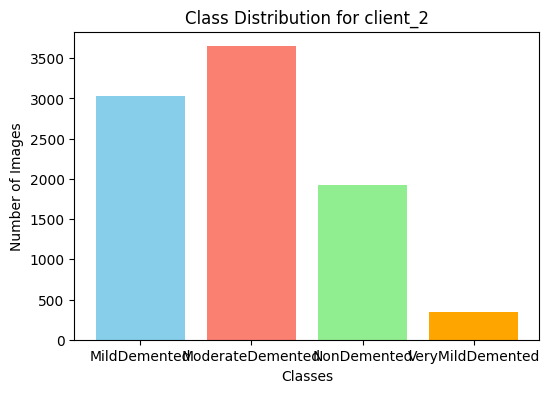

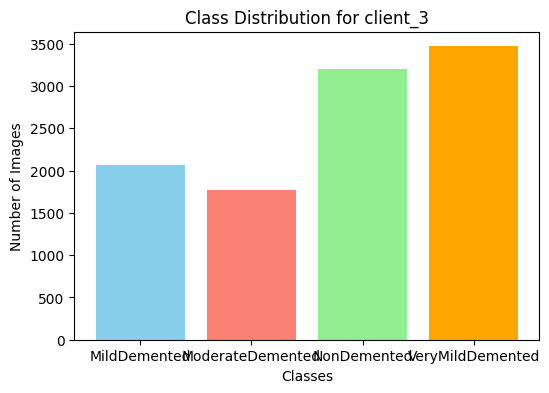

In [ ]:
import os
import shutil
import random
from collections import Counter
import matplotlib.pyplot as plt

BASE_PATH = r""
SOURCE_PATH = os.path.join(BASE_PATH, "data_set")
CLIENTS = ["client_1", "client_2", "client_3"]
CLASSES = [d for d in os.listdir(SOURCE_PATH) if os.path.isdir(os.path.join(SOURCE_PATH, d))]

# Create client/class directories
for client in CLIENTS:
    for cls in CLASSES:
        os.makedirs(os.path.join(BASE_PATH, client, "dataset", cls), exist_ok=True)

# Collect all images per class
class_images = {cls: [] for cls in CLASSES}
for cls in CLASSES:
    class_dir = os.path.join(SOURCE_PATH, cls)
    class_images[cls] = [os.path.join(class_dir, f) for f in os.listdir(class_dir)
                         if f.lower().endswith(('png','jpg','jpeg'))]

# Record distribution
distribution_records = {client: Counter() for client in CLIENTS}

# Distribute images per class
for cls, images in class_images.items():
    random.shuffle(images)
    total = len(images)

    # Random uneven split for heterogeneity
    split_sizes = [random.randint(1, max(1, total // len(CLIENTS))) for _ in CLIENTS]
    scale = total / sum(split_sizes)
    split_sizes = [int(x*scale) for x in split_sizes]

    # Adjust rounding differences
    diff = total - sum(split_sizes)
    for i in range(abs(diff)):
        split_sizes[i % len(split_sizes)] += 1 if diff > 0 else -1

    assert sum(split_sizes) == total, "Split size mismatch!"

    # Copy images to clients
    start = 0
    for client, size in zip(CLIENTS, split_sizes):
        end = start + size
        subset = images[start:end]
        for img in subset:
            dest = os.path.join(BASE_PATH, client, "dataset", cls, os.path.basename(img))
            shutil.copy(img, dest)
        distribution_records[client][cls] += len(subset)
        start = end

# Plot per-client class distributions
for client in CLIENTS:
    counts = distribution_records[client]
    plt.figure(figsize=(6,4))
    plt.bar(counts.keys(), counts.values(), color=['skyblue','salmon','lightgreen','orange'])
    plt.title(f"Class Distribution for {client}")
    plt.xlabel("Classes")
    plt.ylabel("Number of Images")
    plt.show()


In [ ]:
# federated_server.py
# Hard-coded paths version with your bigger MLP

import os
import numpy as np
from tqdm import tqdm
import cv2
import pennylane as qml
import tensorflow as tf
from tensorflow import keras as K
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split

# -------------------- CONFIG --------------------
CLIENTS = ["client_1", "client_2", "client_3"]

CLIENT_PATHS = {
    "client_1": r"C:\Users\ASUS\Desktop\project_1\client_1",
    "client_2": r"C:\Users\ASUS\Desktop\project_1\client_2",
    "client_3": r"C:\Users\ASUS\Desktop\project_1\client_3",
}

GLOBAL_FOLDER = r"C:\Users\ASUS\Desktop\project_1\global"
os.makedirs(GLOBAL_FOLDER, exist_ok=True)

IMG_SIZE = 64
PATCH_SIZE = 2
QUANT_FEATURES_NAME = "quantum_features.npy"
CLIENT_MODEL_WEIGHTS = "client_model.h5"
GLOBAL_MODEL_PATH = os.path.join(GLOBAL_FOLDER, "global_model.h5")

LOCAL_EPOCHS = 20
ROUNDS = 5
BATCH_SIZE = 32
LEARNING_RATE = 1e-3

WIRES = 4
dev = qml.device("default.qubit", wires=WIRES)

# -------------------- QUANTUM CIRCUIT + EXTRACT --------------------
@qml.qnode(dev)
def quantum_patch_circuit(phi):
    qml.RX(phi[0], wires=0)
    qml.RX(phi[1], wires=1)
    qml.RX(phi[2], wires=2)
    qml.RX(phi[3], wires=3)

    qml.CNOT(wires=[0, 1])
    qml.RZ(np.pi/2, wires=1)
    qml.CNOT(wires=[0, 1])

    qml.CNOT(wires=[2, 3])
    qml.RZ(np.pi/2, wires=3)
    qml.CNOT(wires=[2, 3])

    qml.CNOT(wires=[1, 2])
    qml.RZ(np.pi/2, wires=2)
    qml.CNOT(wires=[1, 2])

    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

def extract_q_features(image, patch_size=PATCH_SIZE):
    h, w = image.shape
    features = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size].flatten()
            if patch.shape[0] < WIRES:
                patch = np.concatenate([patch, np.zeros(WIRES - patch.shape[0])])
            features.append(quantum_patch_circuit(patch))
    return np.array(features).flatten()

def compute_and_save_client_features(client_folder, img_size=IMG_SIZE):
    save_path = os.path.join(client_folder, QUANT_FEATURES_NAME)
    if os.path.exists(save_path):
        print(f"[{os.path.basename(client_folder)}] Found existing features, loading.")
        return np.load(save_path, allow_pickle=True)

    dataset_path = os.path.join(client_folder, "dataset")
    if not os.path.isdir(dataset_path):
        raise ValueError(f"Dataset folder missing: {dataset_path}")

    classes = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
    class_to_idx = {c: i for i, c in enumerate(classes)}

    images, labels = [], []
    for cls in classes:
        cls_folder = os.path.join(dataset_path, cls)
        if not os.path.isdir(cls_folder):
            raise ValueError(f"Missing class folder: {cls_folder}")
        for fname in os.listdir(cls_folder):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            fp = os.path.join(cls_folder, fname)
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size)) / 255.0
            images.append(img)
            labels.append(class_to_idx[cls])

    if len(images) == 0:
        raise ValueError(f"No images found in dataset for client: {client_folder}")

    images = np.array(images)
    labels = np.array(labels)

    q_features = []
    print(f"[{os.path.basename(client_folder)}] Extracting quantum features for {len(images)} images...")
    for img in tqdm(images, desc=f"Q-feat {os.path.basename(client_folder)}"):
        q_features.append(extract_q_features(img))
    q_features = np.array(q_features)

    np.save(save_path, q_features)
    np.save(os.path.join(client_folder, "labels.npy"), labels)
    print(f"[{os.path.basename(client_folder)}] Saved quantum features to {save_path}")
    return q_features


def make_model(input_dim, num_classes):
    """Bigger MLP for higher capacity"""
    model = K.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Flatten(),
        layers.BatchNormalization(),

        layers.Dense(1024, kernel_initializer="he_uniform"),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(512, kernel_initializer="he_uniform"),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        layers.Dense(256, kernel_initializer="he_uniform"),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),
        layers.Dropout(0.15),

        layers.Dense(128, kernel_initializer="he_uniform"),
        layers.LeakyReLU(alpha=0.1),
        layers.BatchNormalization(),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(optimizer=K.optimizers.Adam(learning_rate=LEARNING_RATE),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


def get_weights_list(model):
    return model.get_weights()

def set_weights_list(model, weights):
    model.set_weights(weights)

def weights_sub(w1, w0):
    return [a - b for a, b in zip(w1, w0)]

def weights_add(w1, w2):
    return [a + b for a, b in zip(w1, w2)]

def weights_scalar_mul(w, scalar):
    return [scalar * a for a in w]

# --(FedNova)
def federated_train():
    client_datasets = {}
    class_counts_per_client = {}
    global_num_classes = None

    for client in CLIENTS:
        client_folder = CLIENT_PATHS[client]
        q_path = os.path.join(client_folder, QUANT_FEATURES_NAME)
        labels_path = os.path.join(client_folder, "labels.npy")

        if not os.path.exists(q_path) or not os.path.exists(labels_path):
            q_feats = compute_and_save_client_features(client_folder)
        else:
            print(f"[{client}] Loading cached quantum features.")
            q_feats = np.load(q_path, allow_pickle=True)

        labels = np.load(labels_path)
        client_datasets[client] = (q_feats, labels)
        class_counts_per_client[client] = len(labels)
        global_num_classes = max(global_num_classes or 0, len(np.unique(labels)))

    sample_input_dim = client_datasets[CLIENTS[0]][0].shape[1]
    num_classes = global_num_classes
    global_model = make_model(sample_input_dim, num_classes)
    global_model.save(GLOBAL_MODEL_PATH)
    print(f"[global] Initial global model saved at {GLOBAL_MODEL_PATH}")

    N_total = sum(class_counts_per_client.values())

    for r in range(ROUNDS):
        print(f"\n=== Federated Round {r+1}/{ROUNDS} ===")
        w_global = get_weights_list(global_model)

        client_deltas = {}
        client_local_steps = {}
        client_ns = {}

        for client in CLIENTS:
            q_feats, labels = client_datasets[client]
            n_i = len(labels)
            client_ns[client] = n_i

            X_train, X_test, y_train, y_test = train_test_split(
                q_feats, labels, test_size=0.2, random_state=42, stratify=labels
            )

            model = make_model(sample_input_dim, num_classes)
            set_weights_list(model, w_global)

            steps_per_epoch = int(np.ceil(len(X_train) / BATCH_SIZE))
            print(f"[{client}] Local training: n={len(X_train)} steps/epoch={steps_per_epoch} epochs={LOCAL_EPOCHS}")

            history = model.fit(
                X_train, y_train,
                validation_data=(X_test, y_test),
                epochs=LOCAL_EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=1
            )

            client_model_path = os.path.join(client_folder if False else CLIENT_PATHS[client], CLIENT_MODEL_WEIGHTS)
            model.save(client_model_path)
            print(f"[{client}] Saved local model weights to {client_model_path}")

            w_local = get_weights_list(model)
            delta = weights_sub(w_local, w_global)
            local_steps = LOCAL_EPOCHS * steps_per_epoch
            client_deltas[client] = delta
            client_local_steps[client] = local_steps

        mean_steps = sum(client_ns[c] * client_local_steps[c] for c in CLIENTS) / N_total
        print(f"[global] mean_steps (weighted) = {mean_steps:.2f}")

        aggregated_scaled = None
        for c in CLIENTS:
            scaled = weights_scalar_mul(client_deltas[c], 1.0 / client_local_steps[c])
            weighted_scaled = weights_scalar_mul(scaled, client_ns[c] / N_total)
            if aggregated_scaled is None:
                aggregated_scaled = weighted_scaled
            else:
                aggregated_scaled = weights_add(aggregated_scaled, weighted_scaled)

        update = weights_scalar_mul(aggregated_scaled, mean_steps)
        w_new = weights_add(w_global, update)
        set_weights_list(global_model, w_new)

        global_model.save(GLOBAL_MODEL_PATH)
        print(f"[global] Updated & saved global model at {GLOBAL_MODEL_PATH}")

    print("Federated training complete.")

if __name__ == "__main__":
    federated_train()


[client_1] Loading cached quantum features.
[client_2] Loading cached quantum features.
[client_3] Loading cached quantum features.


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


[global] Initial global model saved at C:\Users\ASUS\Desktop\project_1\global\global_model.h5

=== Federated Round 1/5 ===
[client_1] Local training: n=11624 steps/epoch=364 epochs=20
Epoch 1/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.4375 - loss: 1.2098 - val_accuracy: 0.4671 - val_loss: 1.1405
Epoch 2/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5421 - loss: 0.9792 - val_accuracy: 0.5604 - val_loss: 0.9629
Epoch 3/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.6107 - loss: 0.8619 - val_accuracy: 0.6054 - val_loss: 0.8482
Epoch 4/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.6552 - loss: 0.7691 - val_accuracy: 0.6261 - val_loss: 0.8489
Epoch 5/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.6838 - loss: 0.7166 - val_accuracy: 0.6670 - val_loss: 0.7502
Epoch 6/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - accuracy: 0.7148 - loss: 0.6587 - val_accuracy: 0.6629 - val_loss: 0.7595
Epoch 7/20
364/364 ━━━━━━━━━━━━━━━━━

[client_1] Saved local model weights to C:\Users\ASUS\Desktop\project_1\client_1\client_model.h5
[client_2] Local training: n=7156 steps/epoch=224 epochs=20
Epoch 1/20


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


...

224/224 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - accuracy: 0.9426 - loss: 0.1632 - val_accuracy: 0.9034 - val_loss: 0.3464
Epoch 2/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9653 - loss: 0.1061 - val_accuracy: 0.9061 - val_loss: 0.3358
Epoch 3/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9598 - loss: 0.1145 - val_accuracy: 0.8989 - val_loss: 0.3876
Epoch 4/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9651 - loss: 0.0988 - val_accuracy: 0.8939 - val_loss: 0.3509
Epoch 5/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9694 - loss: 0.0873 - val_accuracy: 0.8944 - val_loss: 0.3980
Epoch 6/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9708 - loss: 0.0859 - val_accuracy: 0.9073 - val_loss: 0.4068
Epoch 7/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9663 - loss: 0.0984 - val_accuracy: 0.8916 - val_loss: 0.4007
Epoch 8/20
224/224 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.9729 - loss: 0.0796 - val_accuracy: 0.901

[client_2] Saved local model weights to C:\Users\ASUS\Desktop\project_1\client_2\client_model.h5
[client_3] Local training: n=8404 steps/epoch=263 epochs=20
Epoch 1/20


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


263/263 ━━━━━━━━━━━━━━━━━━━━ 10s 30ms/step - accuracy: 0.9137 - loss: 0.2329 - val_accuracy: 0.8120 - val_loss: 0.5542
Epoch 2/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.9336 - loss: 0.1832 - val_accuracy: 0.8091 - val_loss: 0.6361
Epoch 3/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9386 - loss: 0.1644 - val_accuracy: 0.8139 - val_loss: 0.6904
Epoch 4/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9435 - loss: 0.1530 - val_accuracy: 0.8001 - val_loss: 0.7047
Epoch 5/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9456 - loss: 0.1536 - val_accuracy: 0.8025 - val_loss: 0.7261
Epoch 6/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9454 - loss: 0.1497 - val_accuracy: 0.7858 - val_loss: 0.7566
Epoch 7/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9545 - loss: 0.1289 - val_accuracy: 0.8025 - val_loss: 0.7543
Epoch 8/20
263/263 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.9513 - loss: 0.1312 - val_accuracy: 0.78

[client_3] Saved local model weights to C:\Users\ASUS\Desktop\project_1\client_3\client_model.h5
[global] mean_steps (weighted) = 5918.43
[global] Updated & saved global model at C:\Users\ASUS\Desktop\project_1\global\global_model.h5
Federated training complete.


In [ ]:
import os
import numpy as np
import cv2
import pennylane as qml
from tensorflow import keras as K
from tqdm import tqdm


TEST_RAW_PATH = r"C:\Users\ASUS\Desktop\project_1\test\data_set"
TEST_SAVE_PATH = r"C:\Users\ASUS\Desktop\project_1\test"
QUANT_FEATURES_NAME = "quantum_features.npy"
LABELS_NAME = "labels.npy"

GLOBAL_MODEL_PATH = r"C:\Users\ASUS\Desktop\project_1\global\global_model.h5"
IMG_SIZE = 64
PATCH_SIZE = 2
WIRES = 4

CLASSES = ["MildDemented", "ModerateDemented", "NonDemented", "VeryMildDemented"]
class_to_idx = {c: i for i, c in enumerate(CLASSES)}

dev = qml.device("default.qubit", wires=WIRES)

@qml.qnode(dev)
def quantum_patch_circuit(phi):
    qml.RX(phi[0], wires=0)
    qml.RX(phi[1], wires=1)
    qml.RX(phi[2], wires=2)
    qml.RX(phi[3], wires=3)

    qml.CNOT(wires=[0, 1])
    qml.RZ(np.pi/2, wires=1)
    qml.CNOT(wires=[0, 1])

    qml.CNOT(wires=[2, 3])
    qml.RZ(np.pi/2, wires=3)
    qml.CNOT(wires=[2, 3])

    qml.CNOT(wires=[1, 2])
    qml.RZ(np.pi/2, wires=2)
    qml.CNOT(wires=[1, 2])

    return [qml.expval(qml.PauliZ(i)) for i in range(4)]

def extract_q_features(image, patch_size=PATCH_SIZE):
    h, w = image.shape
    features = []
    for i in range(0, h - patch_size + 1, patch_size):
        for j in range(0, w - patch_size + 1, patch_size):
            patch = image[i:i+patch_size, j:j+patch_size].flatten()
            if patch.shape[0] < WIRES:
                patch = np.concatenate([patch, np.zeros(WIRES - patch.shape[0])])
            features.append(quantum_patch_circuit(patch))
    return np.array(features).flatten()


def compute_and_save_test_features(raw_folder, save_folder=TEST_SAVE_PATH, img_size=IMG_SIZE):
    os.makedirs(save_folder, exist_ok=True)
    save_features_path = os.path.join(save_folder, QUANT_FEATURES_NAME)
    save_labels_path = os.path.join(save_folder, LABELS_NAME)

    if os.path.exists(save_features_path) and os.path.exists(save_labels_path):
        print("Test features already exist. Loading...")
        features = np.load(save_features_path, allow_pickle=True)
        labels = np.load(save_labels_path, allow_pickle=True)
        return features, labels

    images, labels = [], []
    for cls in CLASSES:
        cls_folder = os.path.join(raw_folder, cls)
        if not os.path.isdir(cls_folder):
            continue
        for fname in os.listdir(cls_folder):
            if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            fp = os.path.join(cls_folder, fname)
            img = cv2.imread(fp, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            img = cv2.resize(img, (img_size, img_size)) / 255.0
            images.append(img)
            labels.append(class_to_idx[cls])

    images = np.array(images)
    labels = np.array(labels)

    print(f"[test] Extracting quantum features for {len(images)} images...")
    q_features = []
    for img in tqdm(images, desc="Q-feat test"):
        q_features.append(extract_q_features(img))
    q_features = np.array(q_features)

    np.save(save_features_path, q_features)
    np.save(save_labels_path, labels)
    print(f"[test] Saved quantum features to {save_features_path}")
    return q_features, labels

def test_global_model():
    X_test, y_test = compute_and_save_test_features(TEST_RAW_PATH)
    print("[test] Loading global model...")
    model = K.models.load_model(GLOBAL_MODEL_PATH)
    print("[test] Global model loaded.")

    loss, acc = model.evaluate(X_test, y_test, batch_size=32, verbose=1)
    print(f"[test] Test Loss: {loss:4f} | Test Accuracy: {acc:4f}")

if __name__ == "__main__":
    test_global_model()


Test features already exist. Loading...
[test] Loading global model...
[test] Global model loaded.
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9192 - loss: 0.2522  
[test] Test Loss: 0.252169 | Test Accuracy: 0.919192
